# Galerie cameroun_map — du CSV à la carte, étape par étape

Ce notebook est la porte d'entrée pédagogique du projet. Il ne couvre pas
toutes les options (voir `README.md` pour la référence complète et
`CONTEXTE_PROJET.md` pour les décisions de conception), mais il montre,
dans l'ordre où vous les rencontrerez réellement, les étapes qui produisent
une carte **fiable** — pas seulement une carte qui s'affiche.

**Plan :**

1. Installation et données de démonstration
2. Carte minimale (régions)
3. Vérifier la jointure avant de publier — `carte.valider()`
4. Carte interactive (Folium)
5. Comparer les méthodes de classification
6. Zoom sur une zone — `focus()` (mode A)
7. Subdivisions internes — `drill_down()` (mode B)
8. Nettoyer un fichier brut indépendamment de la carte — `adapter_dataset`
9. Niveau département et limites connues
10. Pour aller plus loin

> Le premier appel à `charger_geo()` télécharge les contours administratifs
> depuis GADM — une connexion internet est nécessaire une seule fois, puis
> tout est mis en cache dans `data/`.


## 1. Installation et données de démonstration

Si le package n'est pas encore installé dans cet environnement :
```bash
pip install -e ".[fuzzy]"
```
(`fuzzy` active le matching approximatif des noms de zone — voir section 3.)

Pour ce notebook, on **simule** un jeu de données plutôt que de dépendre
d'un fichier externe, afin que la galerie soit reproductible immédiatement.
Remplacez `df_regions` par `pd.read_csv("votre_fichier.csv")` pour vos
propres données.


In [1]:
import numpy as np
import pandas as pd

from cameroun_map import CarteCameroun, SCHEMAS_COULEUR

np.random.seed(0)

REGIONS = [
    "Adamaoua", "Centre", "Est", "Extrême-Nord", "Littoral",
    "Nord", "Nord-Ouest", "Ouest", "Sud", "Sud-Ouest",
]

df_regions = pd.DataFrame({
    "region": REGIONS,
    "taux_pauvrete": np.random.uniform(20, 80, len(REGIONS)).round(1),
})
df_regions

,region,taux_pauvrete
0,Adamaoua,52.9
1,Centre,62.9
2,Est,56.2
3,Extrême-Nord,52.7
4,Littoral,45.4
5,Nord,58.8
6,Nord-Ouest,46.3
7,Ouest,73.5
8,Sud,77.8
9,Sud-Ouest,43.0


## 2. Carte minimale (régions)

Le pipeline tient en quatre lignes : charger la géométrie, charger la
donnée, et visualiser. `charger_metrique()` détecte automatiquement les
colonnes de zone et de valeur si elles ne sont pas précisées — ici on les
indique explicitement par clarté pédagogique.


In [4]:
carte = CarteCameroun(niveau="regions")
carte.charger_geo()
carte.charger_metrique(df_regions, col_nom="region", col_valeur="taux_pauvrete")
carte.diagnostiquer()

[download] Téléchargement GADM niveau 1 : https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_CMR_1.json
[ok] 10 entités chargées, sauvegardées dans data\cameroun_gadm_niveau1.geojson
[ok] 10 zones chargées pour le niveau 'regions'

════════════════════════════════════════════════════════════
  DIAGNOSTIC DU DATASET
════════════════════════════════════════════════════════════
  Dimensions : 10 lignes × 2 colonnes
  Colonnes   : ['region', 'taux_pauvrete']

  ✓ Colonne zone détectée : 'region' (10 valeurs uniques)
  ✓ Format LONG simple (une ligne par zone, pas de dimension temporelle)

  Colonnes numériques disponibles comme métrique : ['taux_pauvrete']
════════════════════════════════════════════════════════════

[adapter] Colonne zone utilisée : 'region'
[adapter] Terminé : 10 lignes, 10 valeurs numériques valides
[ok] Jointure réussie — 10/10 zones avec données

── Géométrie (regions) ──────────────────
  Zones        : 10
  Colonne nom  : NAME_1
  CRS          : EPSG:4326
  Colonn

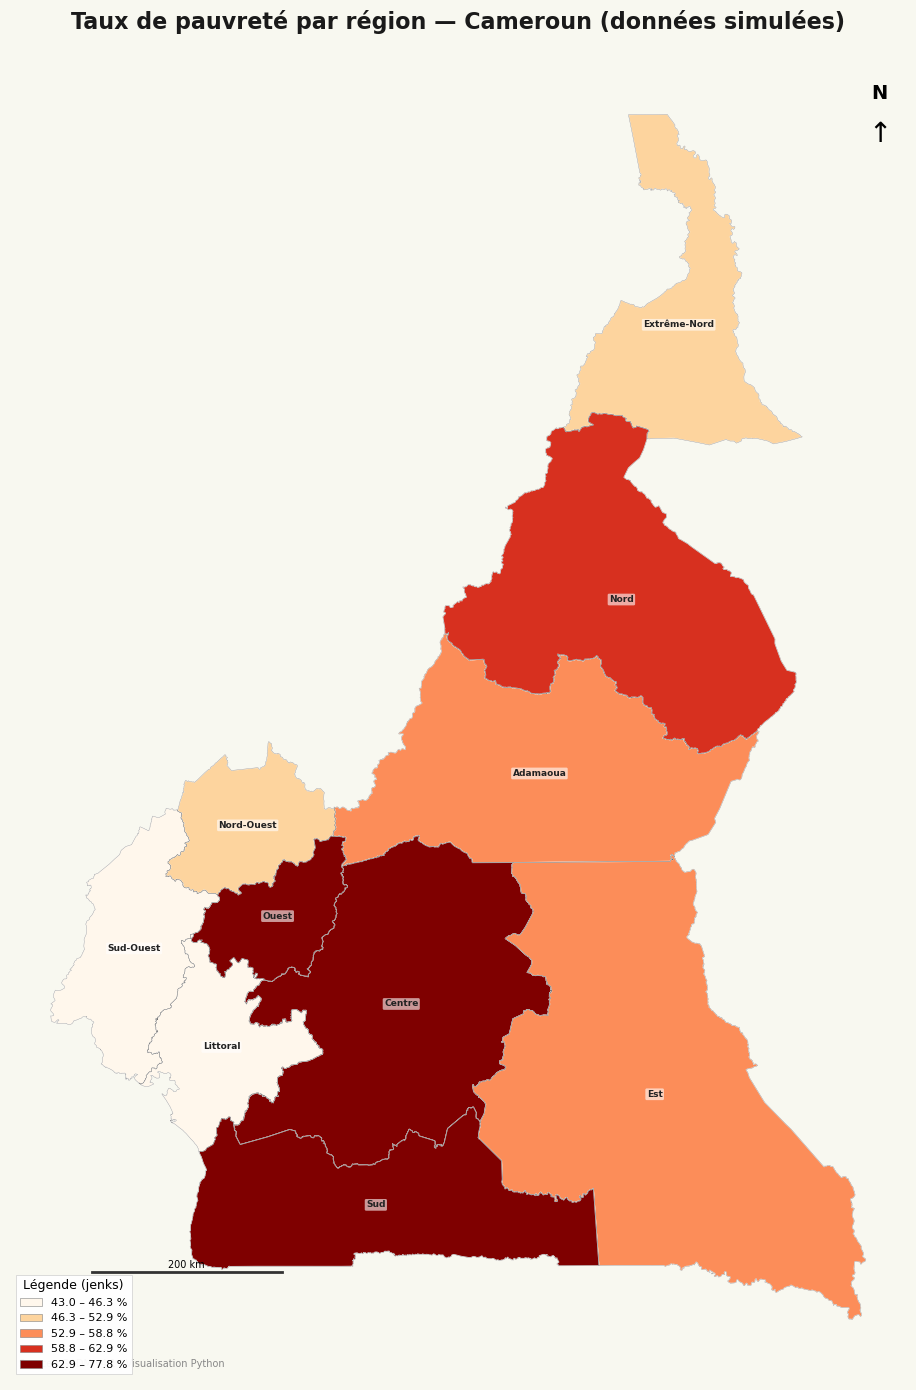

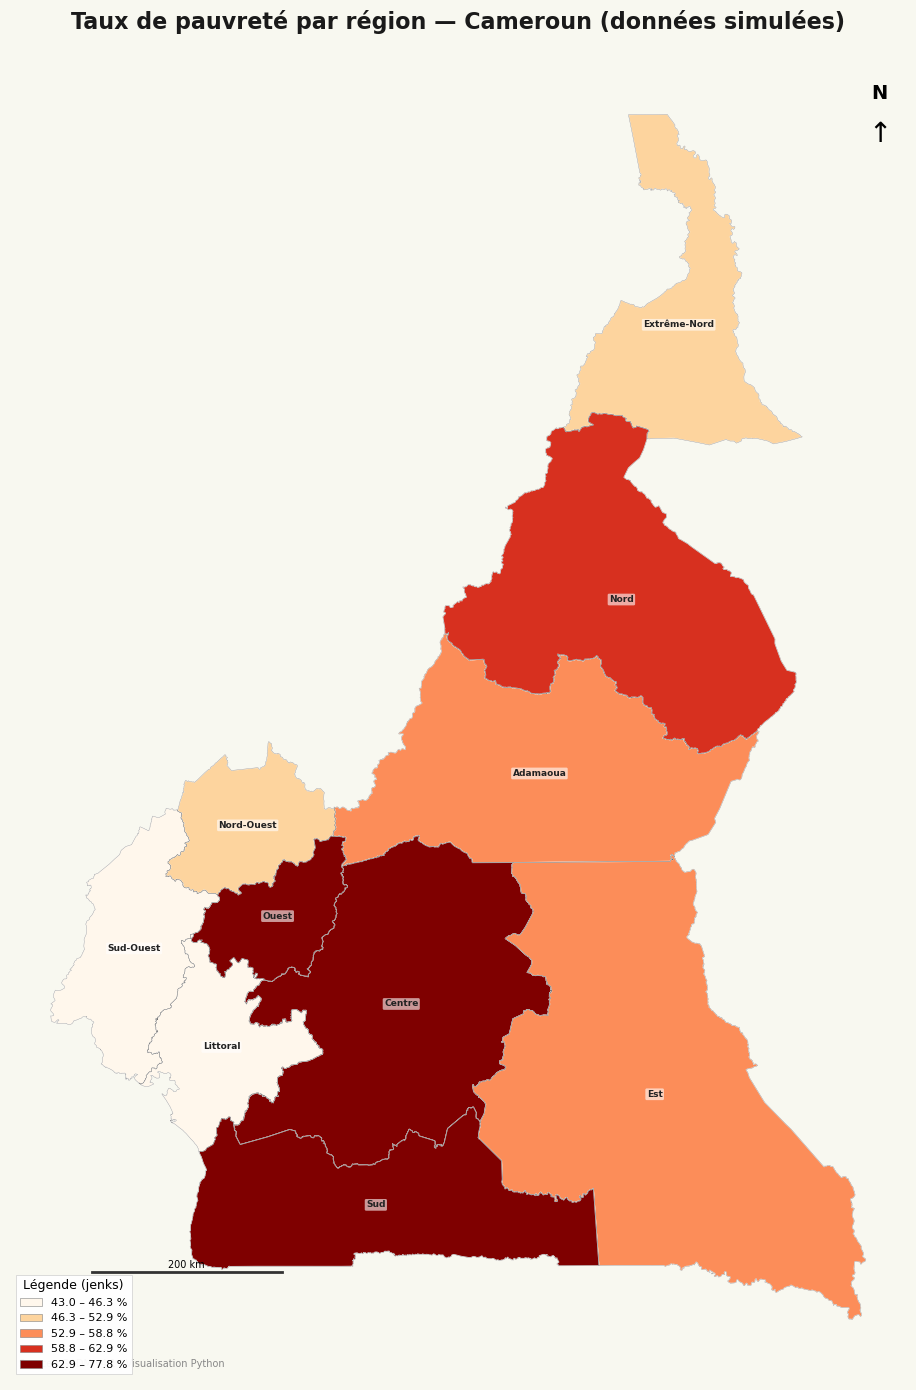

In [6]:
carte.visualiser(
    titre="Taux de pauvreté par région — Cameroun (données simulées)",
    unite="%",
    methode="jenks",
    schema_couleur="OrRd",
    afficher_labels=True,
    sortie=None,   # mettre un chemin .png pour sauvegarder sur disque
)

## 3. Vérifier la jointure avant de publier — `carte.valider()`

`carte.diagnostiquer()` dit *combien* de zones ont une valeur.
`carte.valider()` dit *comment* chaque zone a obtenu sa valeur — exact,
fuzzy avec quel score, ou absent. C'est la différence entre une carte qui
ne plante pas et une carte dont la jointure est vérifiable.

Pour le démontrer, on introduit volontairement un nom mal orthographié et
un doublon orthographique — le genre de défaut qu'on trouve dans un vrai
export de terrain.


In [8]:
df_avec_defauts = pd.DataFrame({
    "region": [
        "Adamaoua", "centre", "Est", "extreme nord", "Littoral",
        "Nord", "Nord Ouest", "ouest", "Sud", "Sud-ouest",
    ],
    "taux_pauvrete": np.random.uniform(20, 80, len(REGIONS)).round(1),
})

carte2 = CarteCameroun(niveau="regions")
carte2.charger_geo()
carte2.charger_metrique(df_avec_defauts, col_nom="region", col_valeur="taux_pauvrete")
table_validation = carte2.valider(seuil_alerte=85)

[cache] Chargement GADM niveau 1 depuis data\cameroun_gadm_niveau1.geojson
[ok] 10 zones chargées pour le niveau 'regions'

════════════════════════════════════════════════════════════
  DIAGNOSTIC DU DATASET
════════════════════════════════════════════════════════════
  Dimensions : 10 lignes × 2 colonnes
  Colonnes   : ['region', 'taux_pauvrete']

  ✓ Colonne zone détectée : 'region' (10 valeurs uniques)
  ✓ Format LONG simple (une ligne par zone, pas de dimension temporelle)
  ℹ 2 valeur(s) de zone non reconnues (normal si niveau département/arrondissement)

  Colonnes numériques disponibles comme métrique : ['taux_pauvrete']
════════════════════════════════════════════════════════════

[adapter] Colonne zone utilisée : 'region'
[adapter] Terminé : 10 lignes, 10 valeurs numériques valides
  [warn] 'thefuzz' non installé — les noms mal orthographiés ne seront PAS corrigés automatiquement (pip install thefuzz python-Levenshtein).
[join] 2 zone(s) sans données : ['Extrême-Nord', 'Nord-

Deux choses à surveiller dans la sortie ci-dessus :

- les lignes `methode=fuzzy` dont le **score** est sous `seuil_alerte` —
  une correspondance a réussi, mais reste douteuse et mérite une
  vérification manuelle ;
- un message `[join][ALERTE]` (affiché au moment de `charger_metrique()`,
  pas dans la table) si deux noms d'origine différents se sont résolus
  vers la **même** zone géographique — les valeurs sont alors moyennées
  automatiquement, ce qui peut masquer une erreur de saisie en amont.

`table_validation` est un DataFrame normal : exportez-le avec
`table_validation.to_csv(...)` pour garder une preuve de la jointure
utilisée dans un livrable.


## 4. Carte interactive (Folium)

Même jointure, rendu HTML autonome — utile pour explorer les valeurs au
survol avant de figer une carte statique pour publication.


In [10]:
carte.visualiser_interactif(
    titre="Taux de pauvreté — Cameroun",
    moteur="folium",
    unite="%",
    sortie="galerie_carte_interactive.html",
)

[ok] Carte interactive sauvegardée : galerie_carte_interactive.html


## 5. Comparer les méthodes de classification

Le choix de la méthode de classification change radicalement la lecture
d'une carte choroplèthe sur les **mêmes données**. Quatre méthodes sont
disponibles : `quantile` (effectifs égaux), `jenks` (ruptures naturelles),
`égale` (intervalles de même largeur), `std` (basé sur l'écart-type).


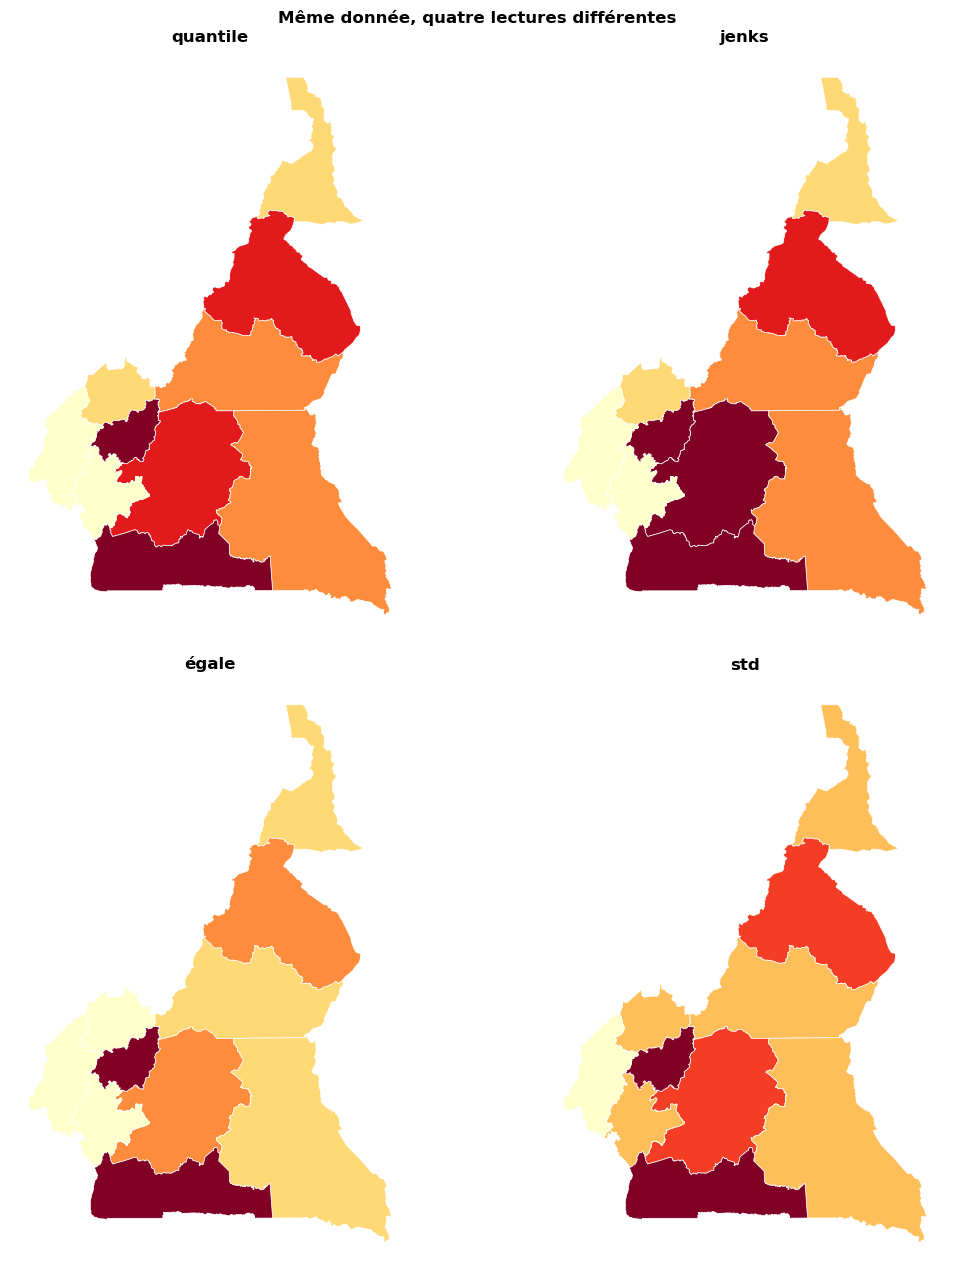

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from cameroun_map import classifier_valeurs

gdf_joint = carte.gdf_joint.to_crs("EPSG:32632")
methodes = ["quantile", "jenks", "égale", "std"]

fig, axes = plt.subplots(2, 2, figsize=(12, 13))
fig.suptitle("Même donnée, quatre lectures différentes", fontweight="bold")

for ax, methode in zip(axes.flat, methodes):
    vals = gdf_joint["valeur"].dropna()
    bornes, etiquettes = classifier_valeurs(vals, methode, 5)
    cmap = plt.get_cmap("YlOrRd", len(bornes) - 1)
    norm = BoundaryNorm(bornes, cmap.N)
    gdf_joint[~gdf_joint["manquant"]].plot(
        ax=ax, column="valeur", cmap=cmap, norm=norm,
        edgecolor="white", linewidth=0.5,
    )
    gdf_joint[gdf_joint["manquant"]].plot(ax=ax, color="#D0D0D0", edgecolor="white")
    ax.set_title(methode, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

**À retenir :** `jenks` et `quantile` donnent rarement la même carte sur un
jeu de données hétérogène. Choisir une méthode sans la justifier dans la
légende ou le rapport, c'est faire un choix éditorial invisible — toujours
mentionner la méthode utilisée à côté d'une carte choroplèthe publiée.


## 6. Zoom sur une zone — `focus()` (mode A)

`focus()` filtre sur une zone précise **sans changer de niveau
administratif**. L'objet retourné est un nouveau `CarteCameroun` — la carte
d'origine (`carte`) reste intacte et réutilisable.


[focus] Zone isolée : 'Littoral' — 1 entité(s)


ValueError: You must provide at least 2 boundaries (1 region) but you passed in array([45.4])

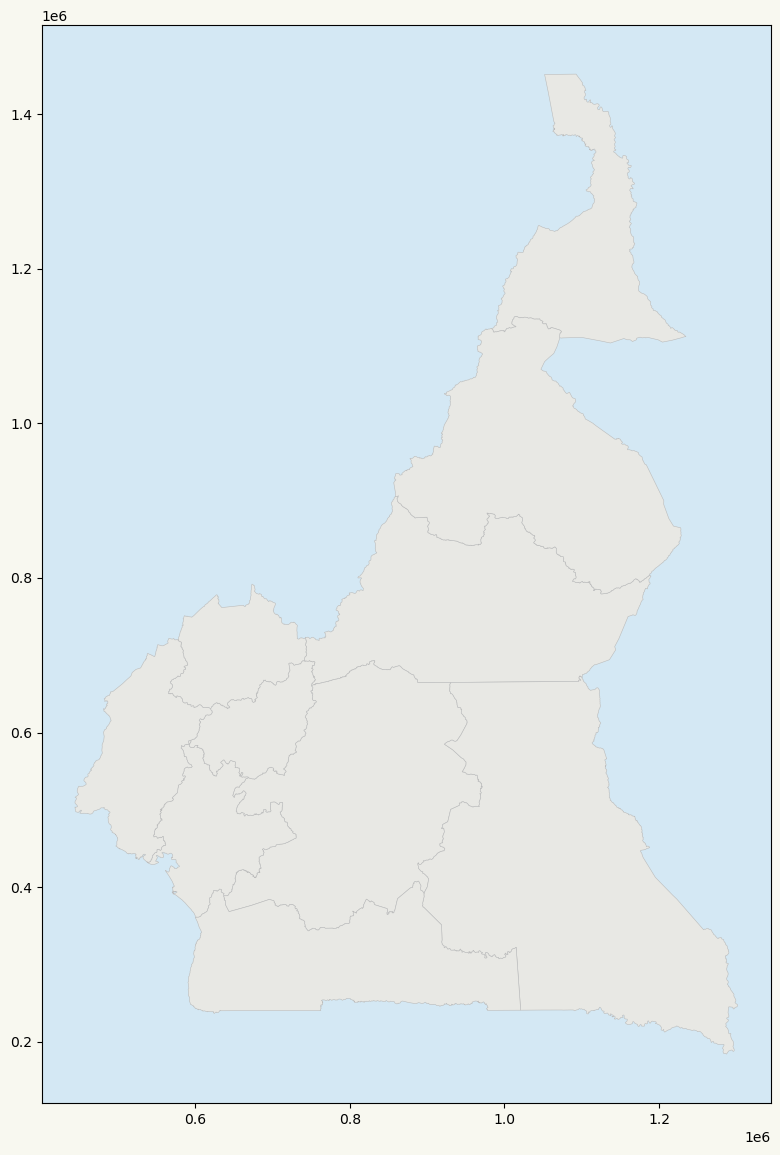

In [14]:
zoom_littoral = carte.focus("Littoral")
zoom_littoral.visualiser(
    titre="Région Littoral — taux de pauvreté",
    unite="%",
    afficher_contexte=True,  # garde le reste du pays en fond grisé
    sortie=None,
)

## 7. Subdivisions internes — `drill_down()` (mode B)

`drill_down()` change de niveau administratif **à l'intérieur** d'une zone
parente — par exemple afficher les départements du Littoral plutôt que la
région entière. Si aucune donnée n'est fournie pour le niveau intérieur, la
géométrie s'affiche tout de même, en hachures grises.


[download] Téléchargement GADM niveau 2 : https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_CMR_2.json
[ok] 58 entités chargées, sauvegardées dans data\cameroun_gadm_niveau2.geojson
[drill_down] 'Littoral' → 4 departements

════════════════════════════════════════════════════════════
  DIAGNOSTIC DU DATASET
════════════════════════════════════════════════════════════
  Dimensions : 4 lignes × 2 colonnes
  Colonnes   : ['departement', 'couverture_vaccinale']

  ✓ Colonne zone détectée : 'departement' (4 valeurs uniques)
  ✓ Format LONG simple (une ligne par zone, pas de dimension temporelle)
  ℹ 4 valeur(s) de zone non reconnues (normal si niveau département/arrondissement)

  Colonnes numériques disponibles comme métrique : ['couverture_vaccinale']
════════════════════════════════════════════════════════════

[adapter] Colonne zone utilisée : 'departement'
[adapter] Terminé : 4 lignes, 4 valeurs numériques valides
[join] 1 zone(s) sans données : ['SanagaMaritime']
[ok] Jointure réus

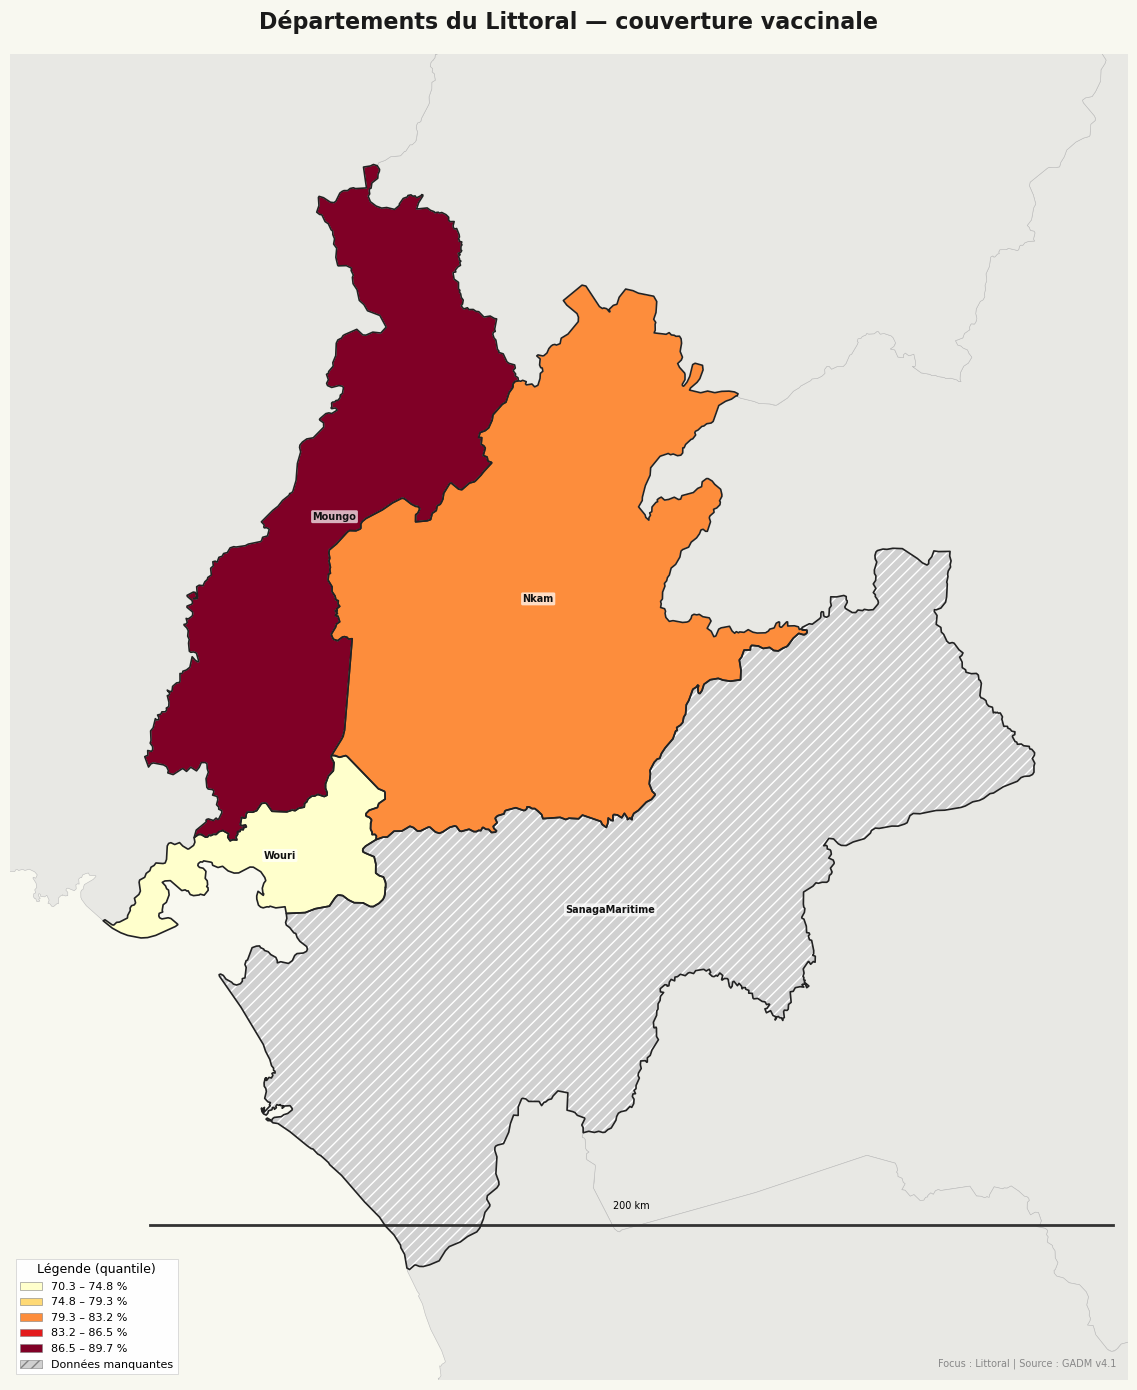

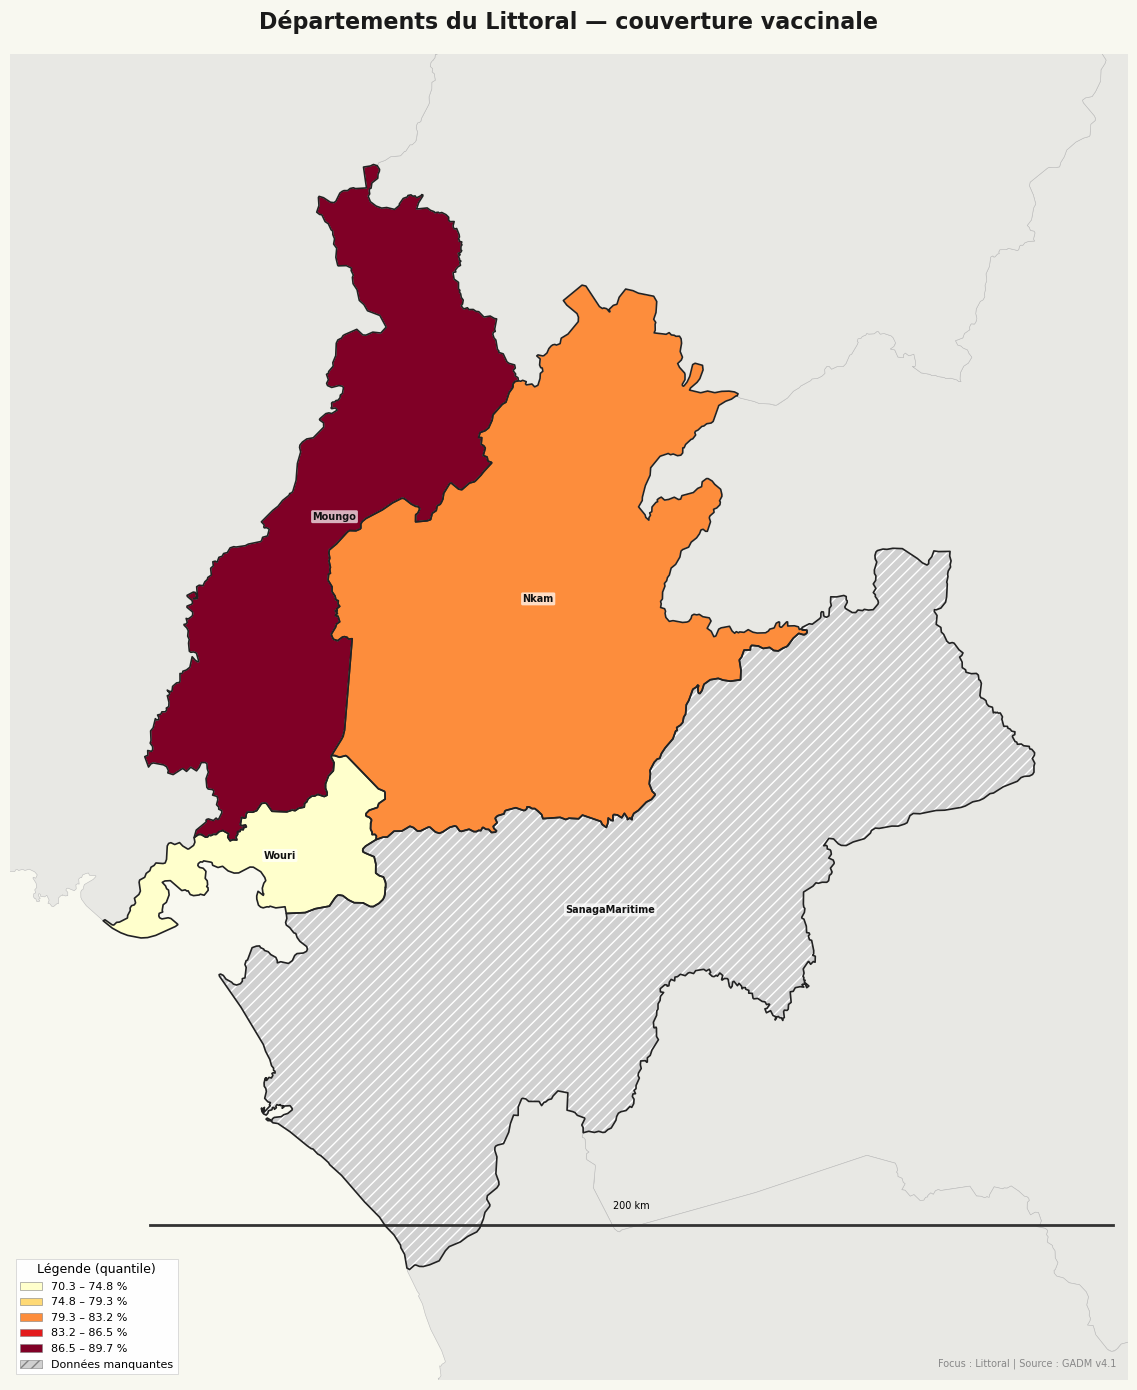

In [16]:
# Données simulées au niveau département, pour les 4 départements du Littoral
df_departements_littoral = pd.DataFrame({
    "departement": ["Wouri", "Moungo", "Nkam", "Sanaga-Maritime"],
    "couverture_vaccinale": np.random.uniform(60, 95, 4).round(1),
})

zoom_departements = carte.drill_down(
    zone="Littoral",
    niveau_interieur="departements",
    df_metrique=df_departements_littoral,
    col_nom_metrique="departement",
    col_valeur_metrique="couverture_vaccinale",
)
zoom_departements.visualiser(
    titre="Départements du Littoral — couverture vaccinale",
    unite="%",
    afficher_contexte=True,
    sortie=None,
)

## 8. Nettoyer un fichier brut indépendamment de la carte — `adapter_dataset`

`adapter_dataset` n'a pas besoin de `CarteCameroun` : c'est un module
autonome utilisable pour nettoyer un fichier, même sans intention
cartographique. L'exemple ci-dessous simule un export réaliste : format
large (une colonne par année), noms de région en minuscules, et une ligne
dupliquée.


In [18]:
from cameroun_map import diagnostiquer_dataset, adapter_dataset

df_brut = pd.DataFrame({
    "region": ["littoral", "centre", "est", "littoral"],  # doublon volontaire
    "2022": [12.1, 8.4, 15.0, 12.6],
    "2023": [11.5, 8.0, 14.2, 11.9],
})

diagnostiquer_dataset(df_brut)


════════════════════════════════════════════════════════════
  DIAGNOSTIC DU DATASET
════════════════════════════════════════════════════════════
  Dimensions : 4 lignes × 3 colonnes
  Colonnes   : ['region', '2022', '2023']

  ✓ Colonne zone détectée : 'region' (3 valeurs uniques)
  ⚠ Format LARGE détecté : colonnes-années ['2022', '2023']
    → nécessite une conversion en format long (voir adapter_dataset)
  ⚠ 2 ligne(s) en doublon pour : ['littoral']
    → agrégation nécessaire avant jointure (somme/moyenne ?)

  Colonnes numériques disponibles comme métrique : ['2022', '2023']
════════════════════════════════════════════════════════════



{'col_zone': 'region',
 'col_code': None,
 'cols_annees': ['2022', '2023'],
 'col_temps': None,
 'format': 'large',
 'niveaux_detectes': {'region': 4},
 'n_doublons': 2,
 'cols_valeur_candidates': ['2022', '2023']}

In [20]:
df_propre = adapter_dataset(df_brut)
df_propre

[adapter] Colonne zone utilisée : 'region'
[transform] Format large → long : 4 lignes → 8 lignes
[adapter] 4 doublon(s) détecté(s) → agrégation par 'moyenne'
[agregation] 8 lignes → 6 lignes (méthode: moyenne)
[adapter] Terminé : 6 lignes, 6 valeurs numériques valides


,zone,temps,valeur
0,centre,2022,8.40
1,centre,2023,8.00
2,est,2022,15.00
3,est,2023,14.20
4,littoral,2022,12.35
5,littoral,2023,11.70


`adapter_dataset` a :

- détecté le format large (`2022`, `2023`) et l'a converti en une ligne par
  zone/période (`melt`) ;
- agrégé le doublon `"littoral"` (moyenne par défaut) ;

mais n'a **pas** corrigé `"littoral"` en `"Littoral"` à ce stade — la
normalisation orthographique vers les noms officiels n'a lieu qu'au moment
de la jointure géographique (`joindre_metrique`), pas dans `adapter_dataset`
lui-même. C'est `carte.charger_metrique()` qui orchestre les deux étapes
dans l'ordre.


## 9. Niveau département et limites connues

Le même pipeline fonctionne à un niveau plus fin (58 départements). Plus le
niveau est fin, moins la fiabilité de la géométrie et la disponibilité de
données officielles correspondantes sont garanties — voir la section
*Limites connues* du `README.md`.


In [24]:
carte_dept = CarteCameroun(niveau="departements")
carte_dept.charger_geo()
# carte_dept.charger_metrique(df_departements)  # nécessite vos 58 départements
print(f"{len(carte_dept.gdf)} départements chargés.")

[cache] Chargement GADM niveau 2 depuis data\cameroun_gadm_niveau2.geojson
[ok] 58 zones chargées pour le niveau 'departements'
58 départements chargés.


## 10. Pour aller plus loin

- **Référence complète des paramètres** : `README.md` à la racine du projet.
- **Décisions de conception et dette technique connue** : `CONTEXTE_PROJET.md`.
- **Export Power BI** (`exporter_pour_powerbi`) : voir la section *Utilisation
  dans Power BI* du `README.md` — non couvert ici car il produit des
  fichiers (`.topojson`, `.csv`) plutôt qu'un rendu dans le notebook.
- **Quartiers via OpenStreetMap** (`niveau="osm_quartiers"`) : non couvert
  ici car il dépend de l'API Overpass (réseau, parfois lent) et de la
  complétude très inégale d'OSM selon les villes.

Règle de base avant de partager une carte produite avec ce projet :
`carte.diagnostiquer()` dit que ça a marché, `carte.valider()` dit que
c'est juste. Les deux sont nécessaires, aucun ne remplace l'autre.
